# CRISP-DM Notebook: Data Preparation Workflow

This notebook is organized into four implementation sections:
1. Clean Data
2. Construct Data
3. Integrate Data
4. Format Data

### Setup: Imports and Helper Utilities

These cells import analysis libraries, configure dataframe display settings, and define helper functions used for readable printing and country mismatch diagnostics.

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.options.display.max_rows = 4000
pd.options.display.max_seq_items = 2000

In [6]:
# for printing readability

class PrintHelper:
  def separator(self, symbol: str = '-', multiple: int = 25) -> None:
    print(symbol * multiple)

  def list_print(self, item_list: list[str], horizontal : bool = False, hori_separator : str = '|',) -> None:
    final_print = ''
    for item in item_list:
      if horizontal:
        final_print += f'{item} {hori_separator}'
      else:
        final_print += item + '\n'
    
    print(final_print)

ph = PrintHelper()

In [7]:
def country_mismatch_report(
    main_df: pd.DataFrame,
    secondary_df: pd.DataFrame,
    main_col: str = 'country',
    secondary_col: str = 'Country Name',
    normalize_func=None
) -> pd.DataFrame:
    """
    Compare country names between main and secondary datasets
    and return a structured report.
    """

    main = main_df.copy()
    secondary = secondary_df.copy()

    # normalize if function provided
    if normalize_func:
        main['norm'] = main[main_col].apply(normalize_func)
        secondary['norm'] = secondary[secondary_col].apply(normalize_func)
    else:
        main['norm'] = main[main_col].astype(str).str.strip().str.lower()
        secondary['norm'] = secondary[secondary_col].astype(str).str.strip().str.lower()

    main_set = set(main['norm'])
    sec_set = set(secondary['norm'])

    missing_in_secondary = sorted(main_set - sec_set)
    extra_in_secondary = sorted(sec_set - main_set)

    report = pd.DataFrame({
        'missing_in_secondary (main only)': pd.Series(missing_in_secondary),
        'extra_in_secondary (secondary only)': pd.Series(extra_in_secondary)
    })

    print("\n===== COUNTRY MISMATCH REPORT =====")
    print(f"Countries in main: {len(main_set)}")
    print(f"Countries in secondary: {len(sec_set)}")
    print(f"Missing in secondary: {len(missing_in_secondary)}")
    print(f"Extra in secondary: {len(extra_in_secondary)}")

    return report

## Clean Data

This section loads all raw datasets, checks schema and missingness, converts types (especially date), and inspects country coverage before harmonization.

In [8]:
# main dataset
main_df = pd.read_csv('data/global_fuel_prices_2020_2026.csv')

# secondary dataset for merging
# exchange_df = pd.read_csv('data/exchange-rate/API_PA.NUS.FCRF_DS2_en_csv_v2_575.csv', skiprows=4) 
gdp_df = pd.read_csv('data/gpd-per-capita/API_NY.GDP.PCAP.CD_DS2_en_csv_v2_245.csv', skiprows=4) # skip rows because each dataset has texts taken for the first four rows
inflation_df = pd.read_csv('data/inflation-rate/API_FP.CPI.TOTL.ZG_DS2_en_csv_v2_287.csv', skiprows=4)

exchange_df = pd.read_csv('data/global-trade/Global_Trade_Exchange_Rates_2000_2025_BALANCED.csv')
conflict_df = pd.read_csv('data/conflict-event/ACLED_conflict_events.csv')
mobility_df = pd.read_csv('data/global-mobility/Global_Mobility_Report.csv')

df_to_merge = {
  # "exchange": exchange_df,
  "gdp": gdp_df,
  "inflation": inflation_df
}

C:\Users\Fikri\AppData\Local\Temp\ipykernel_7504\2177815840.py:11: DtypeWarning: Columns (0: sub_region_2, 1: metro_area, 2: iso_3166_2_code) have mixed types. Specify dtype option on import or set low_memory=False.
  mobility_df = pd.read_csv('data/global-mobility/Global_Mobility_Report.csv')


In [9]:
main_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 27468 entries, 0 to 27467
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   date              27468 non-null  str    
 1   country           27468 non-null  str    
 2   region            27468 non-null  str    
 3   income_level      27468 non-null  str    
 4   subsidy_level     27468 non-null  str    
 5   petrol_usd_liter  27468 non-null  float64
 6   diesel_usd_liter  27468 non-null  float64
 7   lpg_usd_liter     27468 non-null  float64
 8   brent_crude_usd   27468 non-null  float64
 9   tax_percentage    27468 non-null  float64
dtypes: float64(5), str(5)
memory usage: 2.1 MB


In [10]:
# change date to date type

ph.separator()
print('Before:')
print(main_df['date'].head())

main_df['date'] = pd.to_datetime(main_df['date'])
ph.separator()
print('After:')
print(main_df['date'].head())

-------------------------
Before:
0    2020-01-06
1    2020-01-13
2    2020-01-20
3    2020-01-27
4    2020-02-03
Name: date, dtype: str
-------------------------
After:
0   2020-01-06
1   2020-01-13
2   2020-01-20
3   2020-01-27
4   2020-02-03
Name: date, dtype: datetime64[us]


In [11]:
for name, dataset in df_to_merge.items():
  ph.separator()
  print('name')
  print(dataset.info())

# all dataset to merge are missing data of 2025 and 2026

-------------------------
name
<class 'pandas.DataFrame'>
RangeIndex: 266 entries, 0 to 265
Data columns (total 71 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Country Name    266 non-null    str    
 1   Country Code    266 non-null    str    
 2   Indicator Name  266 non-null    str    
 3   Indicator Code  266 non-null    str    
 4   1960            151 non-null    float64
 5   1961            154 non-null    float64
 6   1962            156 non-null    float64
 7   1963            156 non-null    float64
 8   1964            156 non-null    float64
 9   1965            162 non-null    float64
 10  1966            163 non-null    float64
 11  1967            167 non-null    float64
 12  1968            168 non-null    float64
 13  1969            168 non-null    float64
 14  1970            190 non-null    float64
 15  1971            191 non-null    float64
 16  1972            191 non-null    float64
 17  1973           

In [12]:
main_df.head(5)

,date,country,region,income_level,subsidy_level,petrol_usd_liter,diesel_usd_liter,lpg_usd_liter,brent_crude_usd,tax_percentage
0,2020-01-06,United States,North America,High,Low,1.465,1.289,1.093,65.75,59.6
1,2020-01-13,United States,North America,High,Low,1.435,1.319,1.077,65.54,27.6
2,2020-01-20,United States,North America,High,Low,1.446,1.329,1.080,66.51,62.3
3,2020-01-27,United States,North America,High,Low,1.488,1.359,1.125,68.79,44.8
4,2020-02-03,United States,North America,High,Low,1.457,1.341,1.111,68.44,51.4


In [13]:
display(main_df['country'].unique())
display(main_df['country'].nunique())

with open("export/country-text-files/main_countries.txt", "w") as file:
  file.write(f"Unique countries: {main_df['country'].nunique()}\n")
  file.write("Countries:\n")
  for country in main_df['country'].unique():
    file.write(f" - {country}\n")

<StringArray>
[ 'United States',         'Canada',         'Mexico',         'Brazil',
      'Argentina',       'Colombia',          'Chile',           'Peru',
      'Venezuela',        'Ecuador', 'United Kingdom',        'Germany',
         'France',          'Italy',          'Spain',    'Netherlands',
        'Belgium',         'Sweden',         'Norway',        'Denmark',
        'Finland',         'Poland',       'Portugal',         'Greece',
    'Switzerland',        'Austria',        'Ireland',        'Hungary',
 'Czech Republic',        'Romania',         'Russia',        'Ukraine',
         'Turkey',          'China',          'Japan',    'South Korea',
          'India',      'Indonesia',       'Malaysia',       'Thailand',
        'Vietnam',    'Philippines',     'Bangladesh',       'Pakistan',
      'Sri Lanka',          'Nepal',        'Myanmar',      'Singapore',
      'Hong Kong',         'Taiwan',      'Australia',    'New Zealand',
   'Saudi Arabia',            'UAE', 

84

### Clean Exchange and Conflict Sources

The next cells apply source-specific cleaning: selecting relevant columns, handling missing values, and creating early transformed features used later in merging.

In [14]:
##exchange_df dataset

# 3 Columns to be used for modelling
num_cols = ['Exchange_Rate', 'Exports_Value', 'Exports_x_ExchangeRate']

# View dataset
print("=== Exchange Data Preview ===")
display(exchange_df.head())

print("\n=== Info ===")
exchange_df.info()

print("\n=== Missing Values ===")
print(exchange_df[num_cols].isna().sum())

# Keep only relevant columns
exchange_df1 = exchange_df[['Country', 'Year'] + num_cols]

# Handling missing values

## Sort dataset
exchange_df1 = exchange_df1.sort_values(by=['Country', 'Year'])

# Using Interpolation to handle missing values (middle values)
exchange_df1[num_cols] = exchange_df1.groupby('Country')[num_cols].transform(
    lambda x: x.interpolate(method='linear')
)

# Fill remaining missing values (edges)
exchange_df1[num_cols] = exchange_df1.groupby('Country')[num_cols].transform(
    lambda x: x.bfill().ffill()
)

# Final check and filling (if any Nan is still found)
for col in num_cols:
    exchange_df1[col].fillna(exchange_df1[col].median(), inplace=True)

# Feature Transformation
## Use Log transform (handles skewness)
exchange_df1['log_Exchange_Rate'] = np.log1p(exchange_df1['Exchange_Rate'])
exchange_df1['log_Exports_Value'] = np.log1p(exchange_df1['Exports_Value'])
exchange_df1['log_Exports_x_ExchangeRate'] = np.log1p(exchange_df1['Exports_x_ExchangeRate'])

exchange_cleaned = exchange_df1.copy()

# View cleaned dataset
print("=== Exchange Data (Cleaned) Preview ===")
display(exchange_cleaned.head())

=== Exchange Data Preview ===


,Year,Country,ISO3,Exchange_Rate,Exports_Value,Exports_x_ExchangeRate,Data_Type,Source,Dataset_Name
0,2000,Afghanistan,AFG,47.357575,2.079571e+09,9.848343e+10,Historical,World Bank API,Global_Trade_Exchange_Rates
1,2001,Afghanistan,AFG,2358.594605,2.868361e+10,6.765300e+13,Historical,World Bank API,Global_Trade_Exchange_Rates
2,2002,Afghanistan,AFG,205.394167,6.980376e+08,1.433728e+11,Historical,World Bank API,Global_Trade_Exchange_Rates
3,2003,Afghanistan,AFG,39.346933,6.403117e+09,2.519430e+11,Historical,World Bank API,Global_Trade_Exchange_Rates
4,2004,Afghanistan,AFG,5.857542,5.462941e+08,3.199940e+09,Historical,World Bank API,Global_Trade_Exchange_Rates



=== Info ===
<class 'pandas.DataFrame'>
RangeIndex: 5538 entries, 0 to 5537
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Year                    5538 non-null   int64  
 1   Country                 5538 non-null   str    
 2   ISO3                    5538 non-null   str    
 3   Exchange_Rate           5538 non-null   float64
 4   Exports_Value           5512 non-null   float64
 5   Exports_x_ExchangeRate  5512 non-null   float64
 6   Data_Type               5538 non-null   str    
 7   Source                  5538 non-null   str    
 8   Dataset_Name            5538 non-null   str    
dtypes: float64(3), int64(1), str(5)
memory usage: 389.5 KB

=== Missing Values ===
Exchange_Rate              0
Exports_Value             26
Exports_x_ExchangeRate    26
dtype: int64
=== Exchange Data (Cleaned) Preview ===


C:\Users\Fikri\AppData\Local\Temp\ipykernel_7504\3726705344.py:36: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  exchange_df1[col].fillna(exchange_df1[col].median(), inplace=True)
C:\Users\Fikri\AppData\Local\Temp\ipykernel_7504\3726705344.py:36: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through 

,Country,Year,Exchange_Rate,Exports_Value,Exports_x_ExchangeRate,log_Exchange_Rate,log_Exports_Value,log_Exports_x_ExchangeRate
0,Afghanistan,2000,47.357575,2.079571e+09,9.848343e+10,3.878623,21.455427,25.313154
1,Afghanistan,2001,2358.594605,2.868361e+10,6.765300e+13,7.766245,24.079592,31.845413
2,Afghanistan,2002,205.394167,6.980376e+08,1.433728e+11,5.329788,20.363784,25.688714
3,Afghanistan,2003,39.346933,6.403117e+09,2.519430e+11,3.697515,22.580051,26.252469
4,Afghanistan,2004,5.857542,5.462941e+08,3.199940e+09,1.925349,20.118668,21.886398


In [15]:
exchange_cleaned.isna().sum()

Country                       0
Year                          0
Exchange_Rate                 0
Exports_Value                 0
Exports_x_ExchangeRate        0
log_Exchange_Rate             0
log_Exports_Value             0
log_Exports_x_ExchangeRate    0
dtype: int64

### Build Conflict Daily Features

This block cleans ACLED records and aggregates them into daily country-level indicators such as total events and fatalities.

In [16]:
# View dataset and missing value
print("=== Conflict Data Preview ===")
display(conflict_df.head())

print("\n=== Info ===")
conflict_df.info()

print("\n=== Missing Values ===")
print(conflict_df.isna().sum())

# Important Variables

# fatalities (intensity)
# event_type (type of conflict)
# sub_event_type (granularity)

conflict_df1 = conflict_df[['event_date', 'country', 'event_type', 'sub_event_type', 'fatalities']]

# Clean data

# convert date format
conflict_df1['event_date'] = pd.to_datetime(conflict_df1['event_date'])

# missing values

# (1) Fatalities (numeric)
conflict_df1['fatalities'] = conflict_df1['fatalities'].fillna(0)

# Missing fatalities usually means no reported deaths
# Better than dropping rows

# (2) Categorical Columns
conflict_df1['event_type'] = conflict_df1['event_type'].fillna('Unknown')
conflict_df1['sub_event_type'] = conflict_df1['sub_event_type'].fillna('Unknown')

# Feature Transformation

# Aggregate to DAILY event count
conflict_daily = conflict_df1.groupby(['country', 'event_date']).agg(
    total_events=('event_date', 'count'),
    total_fatalities=('fatalities', 'sum'),
    sub_event_diversity=('sub_event_type', 'nunique')
).reset_index()

# Improvement for ML model
# (1) Event type diversity

event_type_diversity = conflict_df1.groupby(['country', 'event_date'])['event_type'].nunique().reset_index()
event_type_diversity.rename(columns={'event_type': 'event_type_diversity'}, inplace=True)

conflict_daily = conflict_daily.merge(event_type_diversity, on=['country', 'event_date'], how='left')

# (2) Average fatalities per event
conflict_daily['avg_fatalities_per_event'] = (
    conflict_daily['total_fatalities'] / conflict_daily['total_events']
).fillna(0)

# Final Key Feature Set
# [
#  'total_events',
#  'total_fatalities',
#  'sub_event_diversity',
#  'event_type_diversity',
#  'avg_fatalities_per_event'
# ]

# View dataset
print("=== Conflict Daily Aggregated Data ===")
display(conflict_daily.head(10))

print("\nShape:", conflict_daily.shape)

=== Conflict Data Preview ===


,event_id,event_date,year,country,region,latitude,longitude,event_type,sub_event_type,actor1,actor2,fatalities,notes_length
0,1,2019-03-16,2019,USA,Middle East,34.457652,79.243512,Battle,Military patrol,Rebel Group,Government,4,69
1,2,2023-03-23,2023,USA,Americas,40.687687,95.215075,Protest,Mob violence,Government,Civilians,5,188
2,3,2024-05-19,2024,India,Asia,21.759217,44.262178,Protest,Peaceful protest,Government,Militia,1,119
3,4,2015-09-11,2015,Pakistan,Americas,22.339349,-14.596424,Violence against civilians,Peaceful protest,Rebel Group,Rebel Group,3,85
4,5,2012-10-04,2012,China,Americas,22.610160,-86.517582,Violence against civilians,Armed clash,Government,Government,3,146



=== Info ===
<class 'pandas.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   event_id        2500 non-null   int64  
 1   event_date      2500 non-null   str    
 2   year            2500 non-null   int64  
 3   country         2500 non-null   str    
 4   region          2500 non-null   str    
 5   latitude        2500 non-null   float64
 6   longitude       2500 non-null   float64
 7   event_type      2500 non-null   str    
 8   sub_event_type  2500 non-null   str    
 9   actor1          2500 non-null   str    
 10  actor2          2500 non-null   str    
 11  fatalities      2500 non-null   int64  
 12  notes_length    2500 non-null   int64  
dtypes: float64(2), int64(4), str(7)
memory usage: 254.0 KB

=== Missing Values ===
event_id          0
event_date        0
year              0
country           0
region            0
latitude          0
longitude  

,country,event_date,total_events,total_fatalities,sub_event_diversity,event_type_diversity,avg_fatalities_per_event
0,Afghanistan,2010-05-10,1,5,1,1,5.0
1,Afghanistan,2010-06-09,1,4,1,1,4.0
2,Afghanistan,2010-06-10,1,3,1,1,3.0
3,Afghanistan,2010-07-25,1,2,1,1,2.0
4,Afghanistan,2010-07-28,1,5,1,1,5.0
5,Afghanistan,2010-10-05,1,5,1,1,5.0
6,Afghanistan,2010-10-21,1,9,1,1,9.0
7,Afghanistan,2010-10-26,1,2,1,1,2.0
8,Afghanistan,2010-12-03,1,3,1,1,3.0
9,Afghanistan,2010-12-27,1,1,1,1,1.0



Shape: (2473, 7)


In [17]:
conflict_daily.isna().sum()

country                     0
event_date                  0
total_events                0
total_fatalities            0
sub_event_diversity         0
event_type_diversity        0
avg_fatalities_per_event    0
dtype: int64

### Validate and Remove Import Artifact Column

The next checks verify whether `Unnamed: 70` is present and entirely null, then remove it from auxiliary datasets.

In [18]:
for key, df in df_to_merge.items():
    print(key, 'Unnamed: 70' in df.columns)

gdp True
inflation True


In [19]:
for key, df in df_to_merge.items():
  print(key, df['Unnamed: 70'].isna().sum() == df.shape[0])


gdp True
inflation True


The checks above show `Unnamed: 70` is an empty import artifact, so the next cell drops it from each dataset in `df_to_merge`.

In [20]:
for dataframe in df_to_merge.values():
  dataframe.drop(columns=['Unnamed: 70'], inplace=True)

# check if it still exist
for key, df in df_to_merge.items():
    print(key, 'Unnamed: 70' in df.columns)

gdp False
inflation False


### Compare and Normalize Country Names (World Bank Inputs)

The next cells generate mismatch reports between main and auxiliary country labels, then inspect likely aliases (for example, alternate spellings or abbreviations) before applying normalization rules.

In [21]:
report_gdp = country_mismatch_report(
    main_df,
    gdp_df,
    main_col='country',
    secondary_col='Country Name',
)

report_gdp.head(20)


===== COUNTRY MISMATCH REPORT =====
Countries in main: 84
Countries in secondary: 266
Missing in secondary: 12
Extra in secondary: 194


,missing_in_secondary (main only),extra_in_secondary (secondary only)
0,czech republic,afghanistan
1,egypt,africa eastern and southern
2,hong kong,africa western and central
3,iran,albania
4,ivory coast,american samoa
5,russia,andorra
6,south korea,antigua and barbuda
7,taiwan,arab world
8,turkey,armenia
9,uae,aruba


In [22]:
[c for c in gdp_df['Country Name'].unique()
 if any(sub in c.lower() for sub in
        ['gypt', 'ira', 'hong', 'zech', 'ivo', 'ssia',
         'korea', 'wan', 'key', 'emirate', 'zuela', 'viet'])]

['United Arab Emirates',
 'Botswana',
 "Cote d'Ivoire",
 'Czechia',
 'Egypt, Arab Rep.',
 'Hong Kong SAR, China',
 'Iran, Islamic Rep.',
 'Iraq',
 'Korea, Rep.',
 "Korea, Dem. People's Rep.",
 'Russian Federation',
 'Rwanda',
 'Venezuela, RB',
 'Viet Nam']

### Export Country Lists for Non-World-Bank Sources

These cells list and export unique country names from exchange and conflict datasets so naming differences can be reviewed consistently.

In [23]:
display(exchange_cleaned['Country'].unique())
display(exchange_cleaned['Country'].nunique())

with open("export/country-text-files/exchange_countries.txt", "w") as file:
  file.write(f"Unique countries: {exchange_cleaned['Country'].nunique()}\n")
  file.write("Countries:\n")
  for country in exchange_cleaned['Country'].unique():
    file.write(f" - {country}\n")

<StringArray>
[                   'Afghanistan',                        'Albania',
                        'Algeria',                 'American Samoa',
                        'Andorra',                         'Angola',
            'Antigua and Barbuda',                      'Argentina',
                        'Armenia',                          'Aruba',
                      'Australia',                        'Austria',
                     'Azerbaijan',                   'Bahamas, The',
                        'Bahrain',                     'Bangladesh',
                       'Barbados',                        'Belarus',
                        'Belgium',                         'Belize',
                          'Benin',                        'Bermuda',
                         'Bhutan',                        'Bolivia',
         'Bosnia and Herzegovina',                       'Botswana',
                         'Brazil',              'Brunei Darussalam',
                    

213

In [24]:
display(conflict_daily['country'].unique())
display(conflict_daily['country'].nunique())

<StringArray>
['Afghanistan',      'Brazil',       'China',    'Ethiopia',       'India',
      'Israel',     'Nigeria',    'Pakistan',      'Russia',     'Somalia',
       'Sudan',       'Syria',      'Turkey',         'USA',     'Ukraine']
Length: 15, dtype: str

15

In [25]:
display(conflict_daily['country'].unique())
display(conflict_daily['country'].nunique())

with open("export/country-text-files/conflict_countries.txt", "w") as file:
  file.write(f"Unique countries: {conflict_daily['country'].nunique()}\n")
  file.write("Countries:\n")
  for country in conflict_daily['country'].unique():
    file.write(f" - {country}\n")

<StringArray>
['Afghanistan',      'Brazil',       'China',    'Ethiopia',       'India',
      'Israel',     'Nigeria',    'Pakistan',      'Russia',     'Somalia',
       'Sudan',       'Syria',      'Turkey',         'USA',     'Ukraine']
Length: 15, dtype: str

15

The exported country text files are used to reconcile naming mismatches (for example, `USA` vs `United States`) before merge-key normalization.

### Normalize and Filter Exchange Countries

This block applies `country_map`, aligns exchange-country labels with `main_df`, and removes non-overlapping country rows before integration.

In [26]:
country_map = {
    "Venezuela, RB": "Venezuela",
    "Egypt, Arab Rep.": "Egypt",
    "Iran, Islamic Rep.": "Iran",
    "Hong Kong SAR, China": "Hong Kong",
    "Korea, Rep.": "South Korea",
    "Russian Federation": "Russia",
    "Turkiye": "Turkey",
    "Viet Nam": "Vietnam",
    "Cote d'Ivoire": "Ivory Coast",
    "Czechia": "Czech Republic",
    "USA": "United States",
}

normalized_exchange = exchange_cleaned['Country'].apply(lambda x: country_map.get(x, x))
display(normalized_exchange[normalized_exchange != exchange_cleaned['Country']].unique())


<StringArray>
[   'Ivory Coast', 'Czech Republic',          'Egypt',      'Hong Kong',
           'Iran',    'South Korea',         'Russia',         'Turkey',
      'Venezuela',        'Vietnam']
Length: 10, dtype: str

In [27]:
print('Unique countries in exchange dataset:', normalized_exchange[normalized_exchange.isin(main_df['country'].unique())].nunique())
print('Unique countries in main dataset:', main_df['country'].nunique())

Unique countries in exchange dataset: 82
Unique countries in main dataset: 84


In [28]:
# drop countries not present in main dataset that are not in exchange dataset
main_countries = set(main_df['country'].unique())
main_countries = {country for country in main_countries if country in normalized_exchange.unique()}
len(main_countries)

# apply back to main dataset
main_df['country'] = main_df['country'].map(lambda x: x if x in main_countries else None)

# apply normalized exchange country names to to original exchange dataset. drop records not present in main dataset
exchange_cleaned['Country'] = exchange_cleaned['Country'].apply(lambda x: country_map.get(x, x))
exchange_cleaned = exchange_cleaned[exchange_cleaned['Country'].isin(main_df['country'].unique())]

# checking the results
print('Number of unique countries in exchange dataset:', exchange_cleaned['Country'][exchange_cleaned['Country'].isin(main_df['country'].unique())].nunique())
print('Number of unique countries in main dataset:', main_df['country'].nunique())

print('Number of Countries present in both datasets:', len(set(exchange_cleaned['Country'].unique()) & set(main_df['country'].unique())))

Number of unique countries in exchange dataset: 82
Number of unique countries in main dataset: 82
Number of Countries present in both datasets: 82


### Normalize Conflict Countries

The next cell applies the same country mapping to conflict data and keeps only countries that exist in the cleaned main dataset.

In [29]:
# apply normalization to conflict dataset and drop records not present in main dataset
conflict_daily['country'] = conflict_daily['country'].apply(lambda x: country_map.get(x, x))
conflict_daily = conflict_daily[conflict_daily['country'].isin(main_df['country'].unique())]


print('Number of unique countries in conflict dataset:', conflict_daily['country'].nunique())
print('Number of unique countries in main dataset:', main_df['country'].nunique())
print('Number of Countries present in both datasets:', len(set(conflict_daily['country'].unique()) & set(main_df['country'].unique())))

Number of unique countries in conflict dataset: 12
Number of unique countries in main dataset: 82
Number of Countries present in both datasets: 12


Conflict records are daily, so the next cell aggregates them to country-year totals to match the merge granularity used by the main dataset.

In [30]:
conflict_yearly = (
    conflict_daily
    .assign(Year=pd.to_datetime(conflict_daily['event_date']).dt.year)
    .groupby(['country', 'Year'])
    .agg({
        'total_events': 'sum',
        'total_fatalities': 'sum'
    })
    .reset_index()
)

conflict_yearly.head(10)

,country,Year,total_events,total_fatalities
0,Brazil,2010,9,26
1,Brazil,2011,15,59
2,Brazil,2012,16,54
3,Brazil,2013,7,24
4,Brazil,2014,11,46
5,Brazil,2015,10,40
6,Brazil,2016,14,60
7,Brazil,2017,7,25
8,Brazil,2018,8,35
9,Brazil,2019,8,34


### Robust Country Key Standardization Across All Inputs

This block defines reusable normalization helpers (regex cleaning and canonical replacements) and applies them to World Bank-style datasets against a normalized main-country reference set.

In [31]:
import re

main_df = main_df[main_df['country'] != 'Taiwan'].copy()

def normalize_country_name(name: str) -> str:
    if pd.isna(name):
        return ''

    s = str(name).strip().lower()
    s = s.replace('&', ' and ')
    s = re.sub(r'[^a-z0-9 ]+', ' ', s)
    s = re.sub(r'\s+', ' ', s).strip()

    replacements = {
        'united states of america': 'united states',
        'russian federation': 'russia',
        'korea rep': 'south korea',
        'korea republic of': 'south korea',
        'iran islamic rep': 'iran',
        'egypt arab rep': 'egypt',
        'venezuela rb': 'venezuela',
        'viet nam': 'vietnam',
        'turkiye': 'turkey',
        'czechia': 'czech republic',
        'united arab emirates': 'uae',
        'hong kong sar china': 'hong kong',
        'cote d ivoire': 'ivory coast',
    }

    return replacements.get(s, s)

def normalize_country_series(s: pd.Series) -> pd.Series:
    return s.apply(normalize_country_name)

def normalize_and_filter_to_main(
    df: pd.DataFrame,
    country_col: str,
    dataset_name: str,
    main_countries: set[str],
) -> pd.DataFrame:
    temp = df.copy()
    before_rows = len(temp)

    temp[country_col] = normalize_country_series(
        temp[country_col].astype(str).str.strip()
    )

    temp = temp[temp[country_col].isin(main_countries)].copy()
    after_rows = len(temp)

    current = set(temp[country_col].dropna().unique())
    extra = current - main_countries
    missing = main_countries - current

    print(f"\n{dataset_name}")
    print(f"Rows kept: {after_rows} / {before_rows} (dropped: {before_rows - after_rows})")

    if not extra and not missing:
        print(f"Both main and {dataset_name} dataset countries match")
    else:
        print(f"Main and {dataset_name} dataset countries do not fully match.")
        if extra:
            print(f"Extra countries in {dataset_name}: {extra}")
        if missing:
            print(f"Missing countries in {dataset_name}: {missing}")

    return temp

# build normalized reference set from main
main_countries = set(
    normalize_country_series(main_df['country'].astype(str).str.strip())
)

# old World Bank-style datasets
for key in df_to_merge:
    df_to_merge[key] = normalize_and_filter_to_main(
        df=df_to_merge[key],
        country_col='Country Name',
        dataset_name=key,
        main_countries=main_countries,
    )


gdp
Rows kept: 82 / 266 (dropped: 184)
Main and gdp dataset countries do not fully match.
Missing countries in gdp: {''}

inflation
Rows kept: 82 / 266 (dropped: 184)
Main and inflation dataset countries do not fully match.
Missing countries in inflation: {''}


In [32]:
# drop records with missing country
main_df = main_df.dropna(subset=['country']).copy()
main_df.isna().sum()

date                0
country             0
region              0
income_level        0
subsidy_level       0
petrol_usd_liter    0
diesel_usd_liter    0
lpg_usd_liter       0
brent_crude_usd     0
tax_percentage      0
dtype: int64

In [33]:
main_df.info()

<class 'pandas.DataFrame'>
Index: 26814 entries, 0 to 27467
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   date              26814 non-null  datetime64[us]
 1   country           26814 non-null  str           
 2   region            26814 non-null  str           
 3   income_level      26814 non-null  str           
 4   subsidy_level     26814 non-null  str           
 5   petrol_usd_liter  26814 non-null  float64       
 6   diesel_usd_liter  26814 non-null  float64       
 7   lpg_usd_liter     26814 non-null  float64       
 8   brent_crude_usd   26814 non-null  float64       
 9   tax_percentage    26814 non-null  float64       
dtypes: datetime64[us](1), float64(5), str(4)
memory usage: 2.3 MB


In [34]:
# normalize all countries to be lower case
def lower_normalize(x):
    if pd.isna(x):
        return pd.NA
    return x.strip().lower()

main_df['country'] = main_df['country'].apply(lower_normalize)

for key in df_to_merge:
    df_to_merge[key]['Country Name'] = df_to_merge[key]['Country Name'].apply(lower_normalize)

exchange_cleaned['Country'] = exchange_cleaned['Country'].apply(lower_normalize)
conflict_yearly['country'] = conflict_yearly['country'].apply(lower_normalize)

In [35]:
main_df['country'].nunique()

82

### Validate Country-Key Alignment

The next function checks that each secondary dataset contains only countries compatible with main-country keys, and reports extras that would break merges.

In [36]:
def check_country_alignment(
    countries: list[str],
    main_countries: set[str],
    dataset_name: str = "dataset"
) -> bool:
    # Normalize inputs (important if you haven't already)
    countries_set = set(map(str, filter(lambda x: x is not None, countries)))

    present = countries_set & main_countries
    missing = countries_set - main_countries

    total = len(countries_set)
    matched = len(present)

    print(f"\nChecking {dataset_name}:")
    print(f"{matched} out of {total} countries present in main dataset")

    if not missing:
        print("No extras found in secondary dataset")
        return True
    else:
        print(f"Extras NOT in main dataset ({len(missing)}):")
        print(sorted(missing))
        return False
    
for key, df in df_to_merge.items():
    check_country_alignment(
        countries=df['Country Name'].dropna().unique().tolist(),
        main_countries=main_countries,
        dataset_name=key
    )

check_country_alignment(
    conflict_yearly['country'].unique().tolist(),
    main_countries,
    "conflict"
)

check_country_alignment(
    exchange_cleaned['Country'].unique().tolist(),
    main_countries,
    "exchange"
)


Checking gdp:
82 out of 82 countries present in main dataset
No extras found in secondary dataset

Checking inflation:
82 out of 82 countries present in main dataset
No extras found in secondary dataset

Checking conflict:
12 out of 12 countries present in main dataset
No extras found in secondary dataset

Checking exchange:
82 out of 82 countries present in main dataset
No extras found in secondary dataset


True

### Profile Missingness Before Imputation

The next two plots show year-wise missing-value counts for GDP and inflation to justify interpolation and forecasting choices.

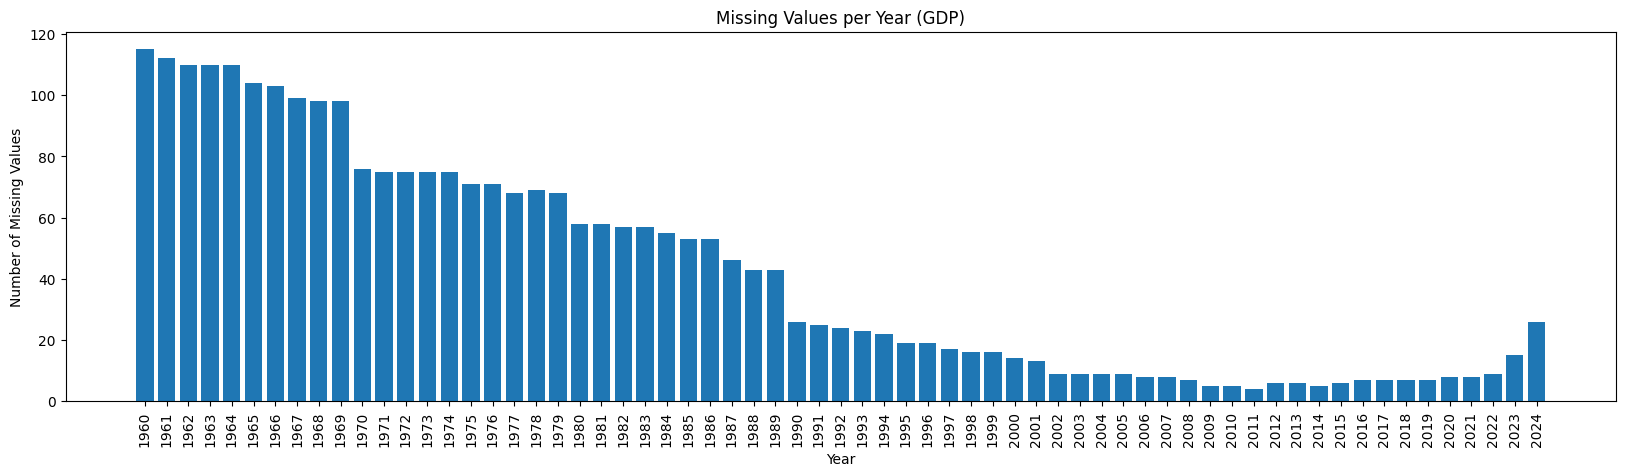

In [37]:
year_cols = [col for col in gdp_df.columns if col.isdigit() and col != '2025']
null_counts = gdp_df[year_cols].isnull().sum()

null_counts = null_counts.sort_index(key=lambda x: x.astype(int))

plt.figure()
plt.bar(null_counts.index, null_counts.values) # type: ignore

plt.xticks(rotation=90)
plt.xlabel('Year')
plt.ylabel('Number of Missing Values')
plt.title('Missing Values per Year (GDP)')

fig = plt.gcf()
fig.set_figwidth(20)

plt.show()

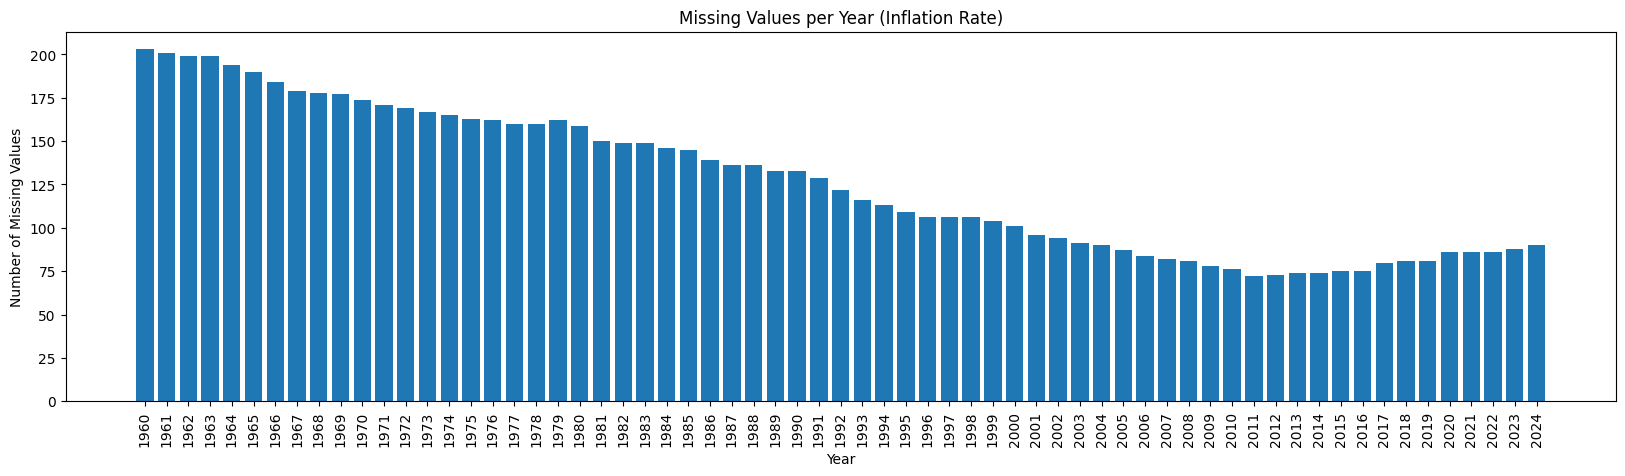

In [38]:
year_cols = [col for col in inflation_df.columns if col.isdigit() and col != '2025']
null_counts = inflation_df[year_cols].isnull().sum()

null_counts = null_counts.sort_index(key=lambda x: x.astype(int))

plt.figure()
plt.bar(null_counts.index, null_counts.values) # type: ignore

plt.xticks(rotation=90)
plt.xlabel('Year')
plt.ylabel('Number of Missing Values')
plt.title('Missing Values per Year (Inflation Rate)')

fig = plt.gcf()
fig.set_figwidth(20)

plt.show()

The following block implements the reusable preprocessing and forecasting pipeline used to fill historical gaps and generate 2025-2026 values.

## Construct Data

This section defines reusable transformation functions, reshapes World Bank datasets from wide to long format, imputes missing values, and constructs forecasted features for downstream merge steps.

In [39]:
import pandas as pd
from sklearn.linear_model import LinearRegression

# Keep only the columns we actually need: country info + year columns.
def clean_worldbank_df(
    df: pd.DataFrame,
    country_col: str = 'Country Name',
    code_col: str = 'Country Code'
) -> pd.DataFrame:
    df = df.copy()

    required_cols = [country_col, code_col]
    for col in required_cols:
        if col not in df.columns:
            raise KeyError(f"Missing required column: {col}")

    # This column is a known import artifact in these files.
    df = df.drop(columns=['Unnamed: 70'], errors='ignore')

    year_cols = [col for col in df.columns if str(col).isdigit()]
    keep_cols = [country_col, code_col] + year_cols

    return df[keep_cols]

# Convert wide year columns into a long format we can model more easily.
def melt_worldbank_df(
    df: pd.DataFrame,
    value_name: str,
    country_col: str = 'Country Name',
    code_col: str = 'Country Code'
) -> pd.DataFrame:
    year_cols = [col for col in df.columns if str(col).isdigit()]

    long_df = df.melt(
        id_vars=[country_col, code_col],
        value_vars=year_cols,
        var_name='Year',
        value_name=value_name
    )

    long_df['Year'] = pd.to_numeric(long_df['Year'], errors='coerce')
    long_df = long_df.dropna(subset=['Year'])
    long_df['Year'] = long_df['Year'].astype(int)

    return long_df

# Keep only the years we care about.
def filter_year_range(
    df: pd.DataFrame,
    start_year: int = -1,
    end_year: int | None = None
) -> pd.DataFrame:
    df = df.copy()

    # if no start year, pick the lowest
    if start_year == -1:
        start_year = df['Year'].min()

    if end_year is None:
        return df[df['Year'] >= start_year].copy()

    return df[df['Year'].between(start_year, end_year)].copy()

# Fill historical gaps per country using interpolation.
def impute_historical_values(
    df: pd.DataFrame,
    value_col: str,
    country_col: str = 'Country Name'
) -> pd.DataFrame:
    df = df.copy()
    df = df.sort_values([country_col, 'Year'])

    df[value_col] = (
        df.groupby(country_col)[value_col]
        .transform(lambda x: x.interpolate(limit_direction='both'))
    )

    return df

def forecast_country_trend(
    group: pd.DataFrame,
    value_col: str,
    country_col: str = 'Country Name',
    code_col: str = 'Country Code',
    forecast_years: list[int] = [2025, 2026],
    trend_window: int = 8,
    fallback_strategy: str = 'country_median',
    global_year_medians: pd.Series | None = None,
    global_overall_median: float | None = None
) -> pd.DataFrame:
    group = group.copy().sort_values('Year')

    # Keep country metadata safe
    if group.empty or country_col not in group.columns or code_col not in group.columns:
        return group

    country_value = group[country_col].iloc[0]
    country_code = group[code_col].iloc[0]

    # Remove forecast years if already present, then regenerate them consistently
    group = group[~group['Year'].isin(forecast_years)].copy()

    fit_group = group.dropna(subset=[value_col]).copy()
    fit_group = fit_group.tail(trend_window)

    n = len(fit_group)

    # CASE 1: enough points for linear regression
    if n >= 2:
        X = fit_group[['Year']]
        y = fit_group[value_col]

        model = LinearRegression()
        model.fit(X, y)

        future_values = model.predict(pd.DataFrame({'Year': forecast_years}))

    # CASE 2: exactly one known value -> flat carry-forward
    elif n == 1:
        single_value = fit_group[value_col].iloc[0]
        future_values = [single_value] * len(forecast_years)

    # CASE 3: zero known values -> fallback imputation
    else:
        if fallback_strategy == 'country_median':
            # country median is impossible here because n == 0 in this filtered window,
            # so fall back to yearly median if available, else overall median
            future_values = []
            for year in forecast_years:
                if global_year_medians is not None and year in global_year_medians.index:
                    val = global_year_medians.loc[year]
                else:
                    val = global_overall_median
                future_values.append(val)

        elif fallback_strategy == 'year_median':
            future_values = []
            for year in forecast_years:
                if global_year_medians is not None and year in global_year_medians.index:
                    val = global_year_medians.loc[year]
                else:
                    val = global_overall_median
                future_values.append(val)

        elif fallback_strategy == 'overall_median':
            future_values = [global_overall_median] * len(forecast_years)

        else:
            # leave unchanged if no valid fallback chosen
            return group

    future_df = pd.DataFrame({
        country_col: [country_value] * len(forecast_years),
        code_col: [country_code] * len(forecast_years),
        'Year': forecast_years,
        value_col: future_values
    })

    existing_years = set(group['Year'])
    future_df = future_df[~future_df['Year'].isin(existing_years)]

    return pd.concat([group, future_df], ignore_index=True)

def forecast_future_values(
    df: pd.DataFrame,
    value_col: str,
    country_col: str = 'Country Name',
    code_col: str = 'Country Code',
    forecast_years: list[int] = [],
    trend_window: int = 8,
    fallback_strategy: str = 'year_median'
) -> pd.DataFrame:
    
    if not forecast_years:
        return df
    df = df.copy()

    # Useful fallback statistics
    global_year_medians = df.groupby('Year')[value_col].median()
    global_overall_median = df[value_col].median()

    results = []

    for country_value, group in df.groupby(country_col):
        group = group.copy()

        if country_col not in group.columns:
            group[country_col] = country_value

        result = forecast_country_trend(
            group=group,
            value_col=value_col,
            country_col=country_col,
            code_col=code_col,
            forecast_years=forecast_years,
            trend_window=trend_window,
            fallback_strategy=fallback_strategy,
            global_year_medians=global_year_medians,
            global_overall_median=global_overall_median
        )

        if country_col not in result.columns:
            result[country_col] = country_value

        results.append(result)

    return pd.concat(results, ignore_index=True)

def fill_remaining_missing(df: pd.DataFrame, value_col: str) -> pd.DataFrame:
    df = df.copy()

    # fill per year using median across countries
    df[value_col] = df.groupby('Year')[value_col].transform(
        lambda x: x.fillna(x.median())
    )

    return df

# Full prep pipeline for one World Bank style dataset.
def prepare_secondary_dataset(
    df: pd.DataFrame,
    value_name: str,
    country_col: str = 'Country Name',
    code_col: str = 'Country Code',
    start_year: int = -1,
    forecast_years: list[int] = [],
    trend_window: int = 8
) -> pd.DataFrame:
    df = clean_worldbank_df(df, country_col=country_col, code_col=code_col)
    print(f'Successfully cleaned {value_name}')

    df = melt_worldbank_df(
        df,
        value_name=value_name,
        country_col=country_col,
        code_col=code_col
    )

    print(f'Successfully melted {value_name}')

    df = filter_year_range(df, start_year=start_year)

    print(f'Successfully filtered {value_name} year from {start_year}')

    df = impute_historical_values(
        df,
        value_col=value_name,
        country_col=country_col
    )

    print(f'Successfully inpute {value_name}')

    df = fill_remaining_missing(
        df,
        value_col=value_name
    )

    print(f'Successfully fill remaining {value_name} values')

    df = forecast_future_values(
        df,
        value_col=value_name,
        country_col=country_col,
        code_col=code_col,
        forecast_years=forecast_years,
        trend_window=trend_window
    )

    print(f'Successfully forcast {value_name} for year {forecast_years}')

    return df

In [40]:
total_zero = 0
total_one = 0
for key, df in df_to_merge.items():
    temp = melt_worldbank_df(df, value_name=key)
    temp = filter_year_range(temp, start_year=2020)

    counts = temp.groupby('Country Name')[key].apply(lambda x: x.notna().sum())
    
    total_zero += (counts == 0).sum()
    total_one += (counts == 1).sum()
    
    print(f'{key}')
    print('0 values:', (counts == 0).sum())
    print('1 value:', (counts == 1).sum())
    print('>=2 values:', (counts >= 2).sum())

print(f'\ntotal zero: {total_zero} | total one: {total_one}')

gdp
0 values: 0
1 value: 0
>=2 values: 82
inflation
0 values: 2
1 value: 0
>=2 values: 80

total zero: 2 | total one: 0


In [41]:
value_names = {
    'gdp': 'gdp_per_capita',
    'inflation': 'inflation_rate'
}

processed_df = {}

def print_out_result(df : pd.DataFrame) -> None:
    null_values = df.isna().sum().sum()
    total_countries = df['Country Name'].nunique()
    columns = df.columns.tolist()

    ph.list_print([
        f'Finished processing `{key}`.', 
        f'Null values present: {null_values}',
        f'Total Countries: {total_countries}',
        f'Columns: {columns}'
        ])


for key, df in df_to_merge.items():
    ph.separator()
    new_df = prepare_secondary_dataset(
        df=df,
        value_name=value_names[key],
        forecast_years=[2025, 2026],
        trend_window=8
    )

    processed_df[key] = new_df
    print_out_result(new_df)

-------------------------
Successfully cleaned gdp_per_capita
Successfully melted gdp_per_capita
Successfully filtered gdp_per_capita year from -1
Successfully inpute gdp_per_capita
Successfully fill remaining gdp_per_capita values
Successfully forcast gdp_per_capita for year [2025, 2026]
Finished processing `gdp`.
Null values present: 0
Total Countries: 82
Columns: ['Country Name', 'Country Code', 'Year', 'gdp_per_capita']

-------------------------
Successfully cleaned inflation_rate
Successfully melted inflation_rate
Successfully filtered inflation_rate year from -1
Successfully inpute inflation_rate
Successfully fill remaining inflation_rate values
Successfully forcast inflation_rate for year [2025, 2026]
Finished processing `inflation`.
Null values present: 0
Total Countries: 82
Columns: ['Country Name', 'Country Code', 'Year', 'inflation_rate']



In [42]:
processed_df['gdp'].info()

<class 'pandas.DataFrame'>
RangeIndex: 5494 entries, 0 to 5493
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Country Name    5494 non-null   str    
 1   Country Code    5494 non-null   str    
 2   Year            5494 non-null   int64  
 3   gdp_per_capita  5494 non-null   float64
dtypes: float64(1), int64(1), str(2)
memory usage: 171.8 KB


In [43]:
print(processed_df['gdp']['Year'].min())
print(processed_df['gdp']['Year'].max())

1960
2026


This step restricts processed secondary datasets to the modeling window (2020-2026) before final country-alignment validation.

In [44]:
for key in processed_df:
  processed_df[key] = filter_year_range(processed_df[key], start_year=2020)

In [45]:
# final check that all countries in processed datasets are present in main dataset
for key in processed_df:
  check_country_alignment(
      countries=processed_df[key]['Country Name'].unique().tolist(),
      main_countries=set(main_df['country'].unique().tolist()),
      dataset_name=key
  )


Checking gdp:
82 out of 82 countries present in main dataset
No extras found in secondary dataset

Checking inflation:
82 out of 82 countries present in main dataset
No extras found in secondary dataset


## Integrate Data

This section joins all prepared secondary sources to the primary fuel-price table by consistent country and year keys.

### Merge World Bank Features into Main Dataset

The next merge loop joins GDP and inflation features to `main_df` using normalized country keys and `Year`, then reports merge coverage and residual missing values.

In [46]:
value_names = {
    'gdp': 'gdp_per_capita',
    'inflation': 'inflation_rate'
}

primary_df = main_df.copy()
primary_df['date'] = pd.to_datetime(primary_df['date'], errors='coerce')
primary_df['Year'] = primary_df['date'].dt.year
primary_df['country'] = primary_df['country'].astype(str).str.strip()
primary_df['country_norm'] = primary_df['country'].apply(lower_normalize)

merged_df = primary_df.copy()

for key, df in processed_df.items():
    value_col = value_names[key]

    temp_df = df[['Country Name', 'Year', value_col]].copy()
    temp_df['Country Name'] = temp_df['Country Name'].astype(str).str.strip()
    temp_df['country_norm'] = temp_df['Country Name'].apply(lower_normalize)
    temp = merged_df.merge(
        temp_df,
        left_on=['country_norm', 'Year'],
        right_on=['country_norm', 'Year'],
        how='left',
        indicator=True
    )

    print(f'\n{key}')
    print(temp['_merge'].value_counts())
    print(f'Missing {value_col}: {temp[value_col].isna().sum()}')

    merged_df = temp.drop(columns=['Country Name', '_merge'])

# Keep merged output aligned with the original primary columns + appended features.
merged_df = merged_df.drop(columns=['country_norm'], errors='ignore')

world_bank_merge = merged_df.copy()


gdp
_merge
both          26814
left_only         0
right_only        0
Name: count, dtype: int64
Missing gdp_per_capita: 0

inflation
_merge
both          26814
left_only         0
right_only        0
Name: count, dtype: int64
Missing inflation_rate: 0


In [47]:
merged_df.isna().sum()

date                0
country             0
region              0
income_level        0
subsidy_level       0
petrol_usd_liter    0
diesel_usd_liter    0
lpg_usd_liter       0
brent_crude_usd     0
tax_percentage      0
Year                0
gdp_per_capita      0
inflation_rate      0
dtype: int64

In [48]:
check_country_alignment(
    countries=exchange_cleaned['Country'].unique().tolist(),
    main_countries=set(merged_df['country'].unique().tolist()),
    dataset_name='gdp'
)


Checking gdp:
82 out of 82 countries present in main dataset
No extras found in secondary dataset


True

In [49]:
display(merged_df.head(5))
display(exchange_cleaned.head(5))

,date,country,region,income_level,subsidy_level,petrol_usd_liter,diesel_usd_liter,lpg_usd_liter,brent_crude_usd,tax_percentage,Year,gdp_per_capita,inflation_rate
0,2020-01-06,united states,North America,High,Low,1.465,1.289,1.093,65.75,59.6,2020,63515.949181,1.233584
1,2020-01-13,united states,North America,High,Low,1.435,1.319,1.077,65.54,27.6,2020,63515.949181,1.233584
2,2020-01-20,united states,North America,High,Low,1.446,1.329,1.080,66.51,62.3,2020,63515.949181,1.233584
3,2020-01-27,united states,North America,High,Low,1.488,1.359,1.125,68.79,44.8,2020,63515.949181,1.233584
4,2020-02-03,united states,North America,High,Low,1.457,1.341,1.111,68.44,51.4,2020,63515.949181,1.233584


,Country,Year,Exchange_Rate,Exports_Value,Exports_x_ExchangeRate,log_Exchange_Rate,log_Exports_Value,log_Exports_x_ExchangeRate
52,algeria,2000,2.000000,3.549421e+09,7.098842e+09,1.098612,21.990050,22.683197
53,algeria,2001,10.025401,3.439264e+10,3.448000e+11,2.400202,24.261108,26.566230
54,algeria,2002,0.710000,2.223211e+10,1.578480e+10,0.536493,23.824804,23.482313
55,algeria,2003,132.888025,4.462068e+10,5.929555e+12,4.897004,24.521463,29.410970
56,algeria,2004,2.666620,6.865605e+09,1.830796e+10,1.299270,22.649790,23.630602


### Merge Exchange and Export Features

These cells standardize exchange years, forecast 2026 exchange-related features, and merge them into the World Bank-enriched main dataset.

In [50]:
# changing exchange dataset year column to date
exchange_cleaned['Year'] = pd.to_datetime(exchange_cleaned['Year'], format='%Y', errors='coerce').dt.year

# filter to years 2020-2026
exchange_cleaned = exchange_cleaned[exchange_cleaned['Year'].between(2020, 2026)].copy()

In [51]:
display(min(exchange_cleaned['Year']))
display(max(exchange_cleaned['Year']))

2020

2025

In [52]:
exchange_features = [
    'Exchange_Rate',
    'Exports_Value',
    'Exports_x_ExchangeRate',
    'log_Exchange_Rate',
    'log_Exports_Value',
    'log_Exports_x_ExchangeRate'
]

forecast_rows = []

for country, group in exchange_cleaned.groupby('Country'):
    group = group.sort_values('Year')

    for feature in exchange_features:
        train = group[['Year', feature]].dropna()

        # Need at least 2 years to fit a line
        if len(train) < 2:
            continue

        X = train[['Year']]
        y = train[feature]

        model = LinearRegression()
        model.fit(X, y)

        pred_2026 = model.predict(pd.DataFrame({'Year': [2026]}))[0]

        forecast_rows.append({
            'Country': country,
            'Year': 2026,
            'feature': feature,
            'value': pred_2026
        })

forecast_2026_long = pd.DataFrame(forecast_rows)

forecast_2026 = forecast_2026_long.pivot_table(
    index=['Country', 'Year'],
    columns='feature',
    values='value'
).reset_index()

forecast_2026.columns.name = None

In [53]:
exchange_with_2026 = pd.concat(
    [exchange_cleaned, forecast_2026],
    ignore_index=True
)

In [54]:
exchange_with_2026.info()

<class 'pandas.DataFrame'>
RangeIndex: 574 entries, 0 to 573
Data columns (total 8 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Country                     574 non-null    str    
 1   Year                        574 non-null    int64  
 2   Exchange_Rate               574 non-null    float64
 3   Exports_Value               574 non-null    float64
 4   Exports_x_ExchangeRate      574 non-null    float64
 5   log_Exchange_Rate           574 non-null    float64
 6   log_Exports_Value           574 non-null    float64
 7   log_Exports_x_ExchangeRate  574 non-null    float64
dtypes: float64(6), int64(1), str(1)
memory usage: 36.0 KB


In [55]:
temp_df = exchange_with_2026[
    ['Country', 'Year',
     'Exchange_Rate', 'Exports_Value', 'Exports_x_ExchangeRate',
     'log_Exchange_Rate', 'log_Exports_Value', 'log_Exports_x_ExchangeRate']
].copy()

temp_df['country_norm'] = temp_df['Country'].apply(lower_normalize)
world_bank_merge['country_norm'] = world_bank_merge['country'].apply(lower_normalize)

merged_df = world_bank_merge.merge(
    temp_df.drop(columns=['Country']),
    on=['country_norm', 'Year'],
    how='left',
    indicator=True
)

print(merged_df['_merge'].value_counts())
print(
    merged_df[
        ['Exchange_Rate', 'Exports_Value', 'Exports_x_ExchangeRate',
         'log_Exchange_Rate', 'log_Exports_Value', 'log_Exports_x_ExchangeRate']
    ].isna().sum()
)

merged_df = merged_df.drop(columns=['country_norm', '_merge'])

merged_with_exchange = merged_df.copy()

_merge
both          26814
left_only         0
right_only        0
Name: count, dtype: int64
Exchange_Rate                 0
Exports_Value                 0
Exports_x_ExchangeRate        0
log_Exchange_Rate             0
log_Exports_Value             0
log_Exports_x_ExchangeRate    0
dtype: int64


In [56]:
merge = np.sort(exchange_with_2026['Country'].unique())
old = np.sort(exchange_cleaned['Country'].unique())

same = True
for i, j in zip(merge, old):
    if i != j:
        print(f'{i} | {j}')
        same = False

if same:
    print("All countries match.")

All countries match.


This validation checks post-merge schema and confirms the exchange-feature join produced the expected structure before adding conflict variables.

In [57]:
merged_with_exchange.info()

<class 'pandas.DataFrame'>
RangeIndex: 26814 entries, 0 to 26813
Data columns (total 19 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   date                        26814 non-null  datetime64[us]
 1   country                     26814 non-null  str           
 2   region                      26814 non-null  str           
 3   income_level                26814 non-null  str           
 4   subsidy_level               26814 non-null  str           
 5   petrol_usd_liter            26814 non-null  float64       
 6   diesel_usd_liter            26814 non-null  float64       
 7   lpg_usd_liter               26814 non-null  float64       
 8   brent_crude_usd             26814 non-null  float64       
 9   tax_percentage              26814 non-null  float64       
 10  Year                        26814 non-null  int32         
 11  gdp_per_capita              26814 non-null  float64       
 12  i

### Merge Conflict Features

The next cells inspect conflict coverage, build a complete country-year grid, forecast 2026 conflict values, and merge conflict indicators into the integrated dataset.

In [58]:
display(conflict_yearly['Year'].unique())
display(conflict_yearly['country'].unique())
display(conflict_yearly.head(5))
display(conflict_yearly['Year'].min())
display(conflict_yearly['Year'].max())
conflict_yearly.info()

array([2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020,
       2021, 2022, 2023, 2024, 2025], dtype=int32)

<StringArray>
[       'brazil',         'china',      'ethiopia',         'india',
        'israel',       'nigeria',      'pakistan',        'russia',
         'sudan',        'turkey',       'ukraine', 'united states']
Length: 12, dtype: str

,country,Year,total_events,total_fatalities
0,brazil,2010,9,26
1,brazil,2011,15,59
2,brazil,2012,16,54
3,brazil,2013,7,24
4,brazil,2014,11,46


np.int32(2010)

np.int32(2025)

<class 'pandas.DataFrame'>
RangeIndex: 186 entries, 0 to 185
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   country           186 non-null    str  
 1   Year              186 non-null    int32
 2   total_events      186 non-null    int64
 3   total_fatalities  186 non-null    int64
dtypes: int32(1), int64(2), str(1)
memory usage: 5.2 KB


In [59]:
# All countries from your main dataset
all_countries = merged_with_exchange['country'].unique()

# Full year range INCLUDING 2026
all_years = list(range(2010, 2027))

full_index = pd.MultiIndex.from_product(
    [all_countries, all_years],
    names=['country', 'Year']
)

conflict_full = (
    conflict_yearly
    .set_index(['country', 'Year'])
    .reindex(full_index)
    .reset_index()
)

# Fill missing with 0
conflict_full[['total_events', 'total_fatalities']] = (
    conflict_full[['total_events', 'total_fatalities']].fillna(0)
)

In [60]:
forecast_rows = []

for country, group in conflict_yearly.groupby('country'):
    group = group.sort_values('Year')

    for feature in ['total_events', 'total_fatalities']:
        train = group[['Year', feature]].dropna()

        if len(train) < 2:
            continue

        X = train[['Year']]
        y = train[feature]

        model = LinearRegression()
        model.fit(X, y)

        pred_2026 = model.predict(pd.DataFrame({'Year': [2026]}))[0]

        # Important: counts should not be negative
        pred_2026 = max(0, pred_2026)

        forecast_rows.append({
            'country': country,
            'Year': 2026,
            feature: pred_2026
        })

forecast_df = pd.DataFrame(forecast_rows)
forecast_2026 = forecast_df.groupby(['country', 'Year']).first().reset_index()

In [61]:
# Work on copies only
base_df = merged_with_exchange.copy()
conflict_merge_df = conflict_full.copy()
forecast_merge_df = forecast_2026.copy()

# Normalize country keys
base_df['country_norm'] = base_df['country'].apply(lower_normalize)
conflict_merge_df['country_norm'] = conflict_merge_df['country'].apply(lower_normalize)
forecast_merge_df['country_norm'] = forecast_merge_df['country'].apply(lower_normalize)

# Merge 2026 forecast into conflict_full
conflict_merge_df = conflict_merge_df.merge(
    forecast_merge_df.drop(columns=['country']),
    on=['country_norm', 'Year'],
    how='left',
    suffixes=('', '_forecast')
)

# Replace only 2026 values with forecasted values
for col in ['total_events', 'total_fatalities']:
    forecast_col = f'{col}_forecast'

    if forecast_col in conflict_merge_df.columns:
        conflict_merge_df[col] = np.where(
            conflict_merge_df['Year'].eq(2026),
            conflict_merge_df[forecast_col].fillna(0),
            conflict_merge_df[col]
        )

# Drop forecast helper columns safely
conflict_merge_df = conflict_merge_df.drop(
    columns=['total_events_forecast', 'total_fatalities_forecast'],
    errors='ignore'
)

# Keep only columns needed for merge
conflict_merge_df = conflict_merge_df[
    ['country_norm', 'Year', 'total_events', 'total_fatalities']
]

# Merge conflict data into base data
final_merged = base_df.merge(
    conflict_merge_df,
    on=['country_norm', 'Year'],
    how='left',
    indicator=True
)

print(final_merged['_merge'].value_counts())

# Because conflict_full should already contain all country-year pairs,
# these should be 0. If not, fill them as 0.
final_merged[['total_events', 'total_fatalities']] = (
    final_merged[['total_events', 'total_fatalities']].fillna(0)
)

print(final_merged[['total_events', 'total_fatalities']].isna().sum())

# Clean helper column
final_merged = final_merged.drop(columns=['country_norm', '_merge'])

_merge
both          26814
left_only         0
right_only        0
Name: count, dtype: int64
total_events        0
total_fatalities    0
dtype: int64


## Format Data

This final section performs dataset-level quality checks and prepares outputs for downstream modeling and reporting.

### Final Output Checks

The next two cells verify final schema (`info`) and missing-value status (`isna().sum()`) before export.

In [62]:
final_merged.info()

<class 'pandas.DataFrame'>
RangeIndex: 26814 entries, 0 to 26813
Data columns (total 21 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   date                        26814 non-null  datetime64[us]
 1   country                     26814 non-null  str           
 2   region                      26814 non-null  str           
 3   income_level                26814 non-null  str           
 4   subsidy_level               26814 non-null  str           
 5   petrol_usd_liter            26814 non-null  float64       
 6   diesel_usd_liter            26814 non-null  float64       
 7   lpg_usd_liter               26814 non-null  float64       
 8   brent_crude_usd             26814 non-null  float64       
 9   tax_percentage              26814 non-null  float64       
 10  Year                        26814 non-null  int32         
 11  gdp_per_capita              26814 non-null  float64       
 12  i

In [63]:
final_merged.isna().sum()

date                          0
country                       0
region                        0
income_level                  0
subsidy_level                 0
petrol_usd_liter              0
diesel_usd_liter              0
lpg_usd_liter                 0
brent_crude_usd               0
tax_percentage                0
Year                          0
gdp_per_capita                0
inflation_rate                0
Exchange_Rate                 0
Exports_Value                 0
Exports_x_ExchangeRate        0
log_Exchange_Rate             0
log_Exports_Value             0
log_Exports_x_ExchangeRate    0
total_events                  0
total_fatalities              0
dtype: int64

In [64]:
final_merged.head(10)

,date,country,region,income_level,subsidy_level,petrol_usd_liter,diesel_usd_liter,lpg_usd_liter,brent_crude_usd,tax_percentage,...,gdp_per_capita,inflation_rate,Exchange_Rate,Exports_Value,Exports_x_ExchangeRate,log_Exchange_Rate,log_Exports_Value,log_Exports_x_ExchangeRate,total_events,total_fatalities
0,2020-01-06,united states,North America,High,Low,1.465,1.289,1.093,65.75,59.6,...,63515.949181,1.233584,2.720617,1.634770e+10,4.447581e+10,1.313889,23.517353,24.518211,7.0,21.0
1,2020-01-13,united states,North America,High,Low,1.435,1.319,1.077,65.54,27.6,...,63515.949181,1.233584,2.720617,1.634770e+10,4.447581e+10,1.313889,23.517353,24.518211,7.0,21.0
2,2020-01-20,united states,North America,High,Low,1.446,1.329,1.080,66.51,62.3,...,63515.949181,1.233584,2.720617,1.634770e+10,4.447581e+10,1.313889,23.517353,24.518211,7.0,21.0
3,2020-01-27,united states,North America,High,Low,1.488,1.359,1.125,68.79,44.8,...,63515.949181,1.233584,2.720617,1.634770e+10,4.447581e+10,1.313889,23.517353,24.518211,7.0,21.0
4,2020-02-03,united states,North America,High,Low,1.457,1.341,1.111,68.44,51.4,...,63515.949181,1.233584,2.720617,1.634770e+10,4.447581e+10,1.313889,23.517353,24.518211,7.0,21.0
5,2020-02-10,united states,North America,High,Low,1.461,1.356,1.105,68.09,15.0,...,63515.949181,1.233584,2.720617,1.634770e+10,4.447581e+10,1.313889,23.517353,24.518211,7.0,21.0
6,2020-02-17,united states,North America,High,Low,1.523,1.390,1.111,70.46,58.8,...,63515.949181,1.233584,2.720617,1.634770e+10,4.447581e+10,1.313889,23.517353,24.518211,7.0,21.0
7,2020-02-24,united states,North America,High,Low,1.597,1.396,1.193,71.61,17.9,...,63515.949181,1.233584,2.720617,1.634770e+10,4.447581e+10,1.313889,23.517353,24.518211,7.0,21.0
8,2020-03-02,united states,North America,High,Low,1.550,1.419,1.156,70.53,55.2,...,63515.949181,1.233584,2.720617,1.634770e+10,4.447581e+10,1.313889,23.517353,24.518211,7.0,21.0
9,2020-03-09,united states,North America,High,Low,1.436,1.286,1.080,65.65,14.7,...,63515.949181,1.233584,2.720617,1.634770e+10,4.447581e+10,1.313889,23.517353,24.518211,7.0,21.0


`Year` was found so it needs to be dropped. Other values need to change their types too.

In [65]:
final_merged.drop(columns=['Year'], inplace=True)

# change data type to categorical
categorical_cols = ['country', 'region', 'income_level', 'subsidy_level']
for col in categorical_cols:
    final_merged[col] = final_merged[col].astype('category')

int_cols = ['total_events', 'total_fatalities']
for col in int_cols:
    final_merged[col] = final_merged[col].astype(int)

final_merged.info()

<class 'pandas.DataFrame'>
RangeIndex: 26814 entries, 0 to 26813
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   date                        26814 non-null  datetime64[us]
 1   country                     26814 non-null  category      
 2   region                      26814 non-null  category      
 3   income_level                26814 non-null  category      
 4   subsidy_level               26814 non-null  category      
 5   petrol_usd_liter            26814 non-null  float64       
 6   diesel_usd_liter            26814 non-null  float64       
 7   lpg_usd_liter               26814 non-null  float64       
 8   brent_crude_usd             26814 non-null  float64       
 9   tax_percentage              26814 non-null  float64       
 10  gdp_per_capita              26814 non-null  float64       
 11  inflation_rate              26814 non-null  float64       
 12  E

#### Feature Engineering

At this stage, the cleaned dataset is converted into a model-ready format.

Main objectives:
- convert categorical fields into numeric representations the model can use
- preserve meaningful order for ordinal categories
- extract and encode temporal patterns from the date column
- keep features aligned for train-test splitting and scaling

These transformations improve learnability while reducing ambiguity in how the model interprets each variable.

##### 1. Nominal Features (No Intrinsic Order)

Columns like `country` and `region` are nominal categories, so one-hot encoding is used.

`drop_first=True` removes one reference level to avoid perfect multicollinearity (dummy variable trap), which is especially important for linear models.

In [66]:
# encode categorical variables
categorical_cols = ['country', 'region']

df_encoded = pd.get_dummies(
    final_merged,
    columns=categorical_cols,
    drop_first=True  # avoids dummy variable trap (recommended for linear models)
)

In [67]:
print(df_encoded['income_level'].unique())
print(df_encoded['subsidy_level'].unique())

['High', 'Middle', 'Low']
Categories (3, str): ['High', 'Low', 'Middle']
['Low', 'High', 'Medium', 'Very High']
Categories (4, str): ['High', 'Low', 'Medium', 'Very High']


##### 2. Ordinal Features (Meaningful Order)

`income_level` and `subsidy_level` contain ranked categories, so they are encoded with `OrdinalEncoder` using a fixed order: Low < Medium < High < Very High.

This preserves relative ranking information without treating categories as unrelated labels.

In [68]:
from sklearn.preprocessing import OrdinalEncoder

df_encoded['income_level'] = df_encoded['income_level'].cat.rename_categories({'Middle': 'Medium'})

encoder = OrdinalEncoder(categories=[['Low', 'Medium', 'High', 'Very High'],
                                     ['Low', 'Medium', 'High', 'Very High']])

df_encoded[['income_level', 'subsidy_level']] = encoder.fit_transform(
    df_encoded[['income_level', 'subsidy_level']]
)

In [69]:
df_encoded['income_level'] = df_encoded['income_level'].astype(int)
df_encoded['subsidy_level'] = df_encoded['subsidy_level'].astype(int)

display(df_encoded[['income_level', 'subsidy_level']].info())

display(df_encoded['income_level'].unique())
display(df_encoded['subsidy_level'].unique())

<class 'pandas.DataFrame'>
RangeIndex: 26814 entries, 0 to 26813
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   income_level   26814 non-null  int64
 1   subsidy_level  26814 non-null  int64
dtypes: int64(2)
memory usage: 419.1 KB


None

array([2, 1, 0])

array([0, 2, 1, 3])

##### 3. Temporal Features from Date

The `date` field is decomposed into interpretable time signals:
- `year` for long-term trend
- `month` and `day_of_week` for calendar effects

Cyclical encoding (`sin`/`cos`) is applied to month and day-of-week so that boundary values remain close (for example, December is close to January).
A monotonic `days_since_start` feature is also created to represent elapsed time since the first observation.

In [70]:
df_encoded = df_encoded.sort_values('date')  # important for time consistency

df_encoded['year'] = df_encoded['date'].dt.year
df_encoded['month'] = df_encoded['date'].dt.month
df_encoded['day_of_week'] = df_encoded['date'].dt.dayofweek

In [71]:
# Month (12-cycle)
df_encoded['month_sin'] = np.sin(2 * np.pi * df_encoded['month'] / 12)
df_encoded['month_cos'] = np.cos(2 * np.pi * df_encoded['month'] / 12)

# Day of week (7-cycle)
df_encoded['dow_sin'] = np.sin(2 * np.pi * df_encoded['day_of_week'] / 7)
df_encoded['dow_cos'] = np.cos(2 * np.pi * df_encoded['day_of_week'] / 7)

In [72]:
df_encoded['days_since_start'] = (df_encoded['date'] - df_encoded['date'].min()).dt.days

In [73]:
df_encoded = df_encoded.drop(columns=['date', 'month', 'day_of_week'])

In [74]:
df_encoded[['month_sin', 'month_cos', 'dow_sin', 'dow_cos', 'days_since_start']].info()

<class 'pandas.DataFrame'>
Index: 26814 entries, 0 to 26813
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   month_sin         26814 non-null  float64
 1   month_cos         26814 non-null  float64
 2   dow_sin           26814 non-null  float64
 3   dow_cos           26814 non-null  float64
 4   days_since_start  26814 non-null  int64  
dtypes: float64(4), int64(1)
memory usage: 1.2 MB


In [75]:
df_encoded.info()

<class 'pandas.DataFrame'>
Index: 26814 entries, 0 to 26813
Columns: 110 entries, income_level to days_since_start
dtypes: bool(87), float64(17), int32(1), int64(5)
memory usage: 7.0 MB


In [76]:
df_encoded.isna().sum().sum()

np.int64(0)

##### 4. Train-Test Split Strategy

The target variable is `petrol_usd_liter`, and all other columns are used as predictors.

Because this is time-ordered data, `shuffle=False` is used to prevent leakage from future records into training.

In [77]:
from sklearn.model_selection import train_test_split

feature_set = df_encoded.drop(columns=['petrol_usd_liter'])  # replace with your target column
target_variable = df_encoded['petrol_usd_liter']

X_train, X_test, y_train, y_test = train_test_split(feature_set, target_variable, test_size=0.2, shuffle=False) # no shuffle for time series

##### 5. Feature Scaling

`StandardScaler` is applied only to selected numeric predictors so magnitudes are comparable across features.

Ordinal and count-like fields are excluded from scaling here to preserve their direct interpretability and avoid unnecessary distortion.

In [78]:
# scale for models that need it
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
exclude_cols = ['total_events', 'total_fatalities', 'income_level', 'subsidy_level']  # these are counts, may not need scaling

numeric_cols = X_train.select_dtypes(include=['int64', 'float64']).columns
numeric_cols = [col for col in numeric_cols if col not in exclude_cols]

X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])

X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

### Export Artifacts

This export cell writes the finalized merged dataset to CSV and Excel in the `export` directory.

In [79]:
# export new merged dataset
final_merged.to_csv('export/merged/merged-dataset.csv', index=False)
final_merged.to_excel('export/merged/merged-dataset.xlsx', index=False)

In [80]:
# export encoded dataset prior to train-test split
df_encoded.to_csv('export/encoded/encoded-dataset.csv', index=False)
df_encoded.to_excel('export/encoded/encoded-dataset.xlsx', index=False)

In [81]:
# export split encoded datasets
X_train.to_csv('export/split-data/X_train.csv', index=False)
X_train.to_excel('export/split-data/X_train.xlsx', index=False)
y_train.to_csv('export/split-data/y_train.csv', index=False)
y_train.to_excel('export/split-data/y_train.xlsx', index=False)
X_test.to_csv('export/split-data/X_test.csv', index=False)
X_test.to_excel('export/split-data/X_test.xlsx', index=False)